This notebook allows:
- Predicting any future year by changing only one cell
- Automatic comparison with 2024
- New urban expansion detection
- Area statistics generation
- Multi-year simulation support

## # Generalized CA-Markov Prediction Pipeline

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports

In [13]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

## Paths

In [14]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/final_classified_masks"

## Change Only This Cell

In [55]:
BASE_YEAR = 2024
TARGET_YEAR = 2027

## Load Base LULC

In [56]:
with rasterio.open(f"{BASE_DIR}/{BASE_YEAR}_mask.tif") as src:
    lulc_base = src.read(1)
    profile = src.profile

## CA-Markov Function

In [57]:
kernel = np.array([
    [1,1,1],
    [1,0,1],
    [1,1,1]
])

def run_ca(lulc, years):

    pred = lulc.copy()

    for _ in range(years):

        urban_neighbors = convolve((pred == 3).astype(int), kernel)

        growth = (
            (pred == 2) &
            (urban_neighbors >= 4)
        )

        pred[growth] = 3

    return pred

## Compute Prediction Interval

In [58]:
years_to_predict = TARGET_YEAR - BASE_YEAR
print(f"Predicting {years_to_predict} years ahead")

Predicting 3 years ahead


## Run Prediction

In [59]:
lulc_pred = run_ca(lulc_base, years=years_to_predict)

## Save Prediction

In [60]:
OUT_FP = f"{BASE_DIR}/{TARGET_YEAR}_predicted_mask.tif"

with rasterio.open(OUT_FP, "w", **profile) as dst:
    dst.write(lulc_pred, 1)

print(f"Prediction saved: {OUT_FP}")

Prediction saved: /content/drive/MyDrive/Colab Notebooks/final_classified_masks/2027_predicted_mask.tif


## Comparison With 2024

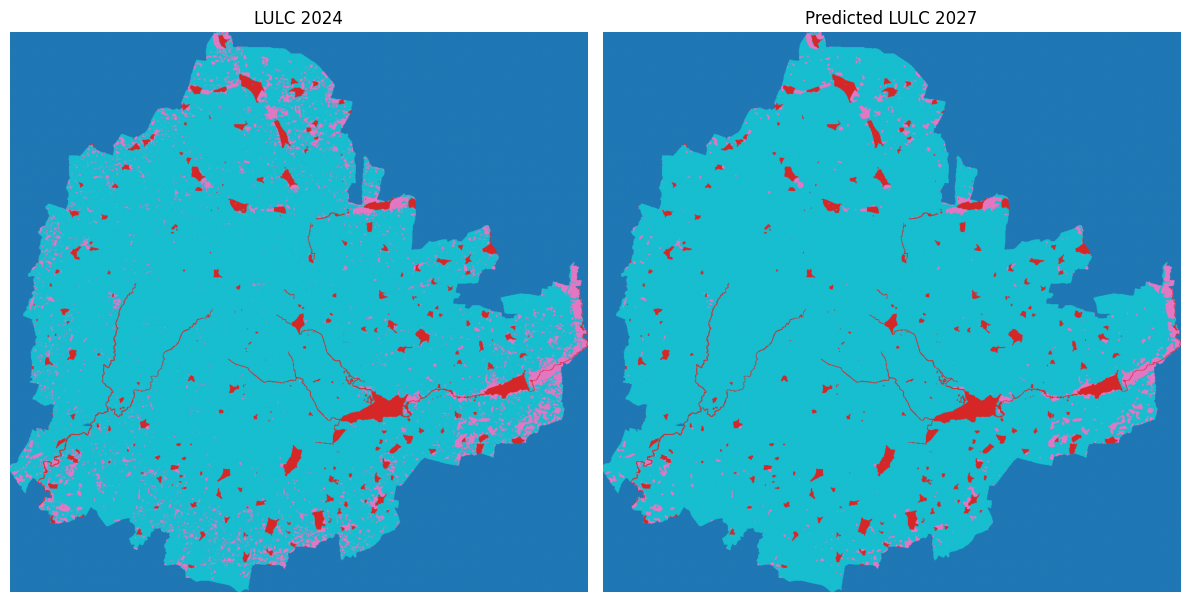

In [61]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(lulc_base, cmap="tab10")
axs[0].set_title(f"LULC {BASE_YEAR}")
axs[0].axis("off")

axs[1].imshow(lulc_pred, cmap="tab10")
axs[1].set_title(f"Predicted LULC {TARGET_YEAR}")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## New Urban Expansion

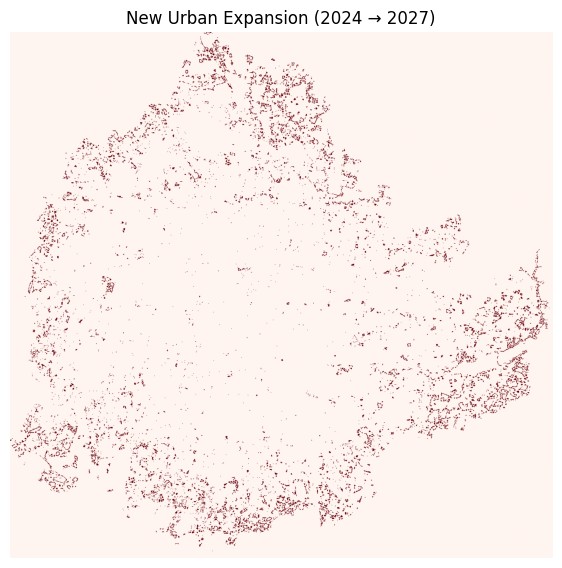

In [62]:
new_urban = (
    (lulc_pred == 3) &
    (lulc_base != 3)
)

plt.figure(figsize=(7,7))
plt.imshow(new_urban, cmap="Reds")
plt.title(f"New Urban Expansion ({BASE_YEAR} → {TARGET_YEAR})")
plt.axis("off")
plt.show()

## Area Statistics

In [63]:
PIXEL_SIZE_M = 30
PIXEL_AREA_KM2 = (PIXEL_SIZE_M ** 2) / 1e6

classes = {
    1: "Water",
    2: "Vegetation",
    3: "Built-up"
}

records = []

for cls, name in classes.items():

    base_area = np.sum(lulc_base == cls) * PIXEL_AREA_KM2
    pred_area = np.sum(lulc_pred == cls) * PIXEL_AREA_KM2

    records.append([
        name,
        round(base_area, 2),
        round(pred_area, 2),
        round(pred_area - base_area, 2)
    ])

area_df = pd.DataFrame(records, columns=[
    "Class",
    f"Area_{BASE_YEAR}",
    f"Area_{TARGET_YEAR}",
    "Change"
])

print(area_df)

        Class  Area_2024  Area_2027  Change
0       Water      32.33      32.33    0.00
1  Vegetation      51.43      21.59  -29.84
2    Built-up     636.08     665.92   29.84


## Area Change Plot

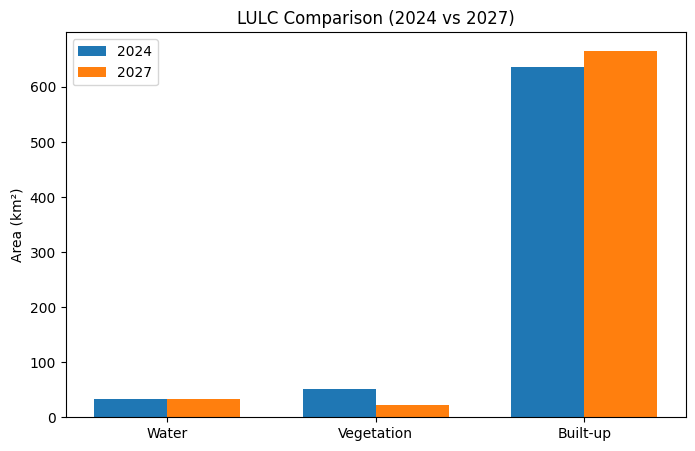

In [64]:
x = np.arange(len(area_df))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    area_df[f"Area_{BASE_YEAR}"],
    width,
    label=str(BASE_YEAR)
)

plt.bar(
    x + width/2,
    area_df[f"Area_{TARGET_YEAR}"],
    width,
    label=str(TARGET_YEAR)
)

plt.xticks(x, area_df["Class"])
plt.ylabel("Area (km²)")
plt.title(f"LULC Comparison ({BASE_YEAR} vs {TARGET_YEAR})")
plt.legend()

plt.show()

## Urban Growth Percentage

In [65]:
urban_2024 = np.sum(lulc_base == 3)
urban_future = np.sum(lulc_pred == 3)

increase_percent = (
    (urban_future - urban_2024)
    / urban_2024
) * 100

print(f"Urban growth increase: {increase_percent:.2f}%")

Urban growth increase: 4.69%


## Directional Urban Growth Analysis

In [66]:
def directional_stats(old, new):

    diff = (new == 3) & (old != 3)

    h, w = diff.shape

    zones = {
        "North": diff[:h//3, :],
        "Center": diff[h//3:2*h//3, :],
        "South": diff[2*h//3:, :]
    }

    stats = {
        k: int(np.sum(v))
        for k, v in zones.items()
    }

    return stats

stats = directional_stats(lulc_base, lulc_pred)

print(stats)

{'North': 9836, 'Center': 9855, 'South': 13470}


## Multi-Year Prediction

In [67]:
TARGET_YEARS = [2025, 2030, 2035, 2040, 2050]

for target in TARGET_YEARS:

    years_ahead = target - BASE_YEAR

    pred = run_ca(lulc_base, years_ahead)

    out_fp = f"{BASE_DIR}/{target}_predicted_mask.tif"

    with rasterio.open(out_fp, "w", **profile) as dst:
        dst.write(pred, 1)

    print(f"Saved {target}")

Saved 2025


Saved 2030


Saved 2035


Saved 2040


Saved 2050
